# Playing Card Image Classification

**Authors:**
- Alexander Ottelien
- Daniel Fischer
- Wyatt Jens

This Jupyter notebook implements image classification for playing cards using two different neural network models: a Convolutional Neural Network (CNN) and a Deep Neural Network (DNN).

In [1]:
import numpy as np
import tensorflow.keras as keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import backend as K
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

2023-12-08 09:17:56.480890: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-12-08 09:17:57.390158: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Baseline Model 

This cell defines and trains the baseline Convolutional Neural Network (CNN) model for playing card image classification. The model architecture includes convolutional layers with max pooling, followed by fully connected layers. The training is performed on a dataset loaded using TensorFlow's image dataset utilities, with data preprocessing such as normalization. The training history, including accuracy, is stored in the variable history_base and can be visualized later.

In [2]:
cnn_epochs = 25
cnn_batchsize = 32
width = 150
height = 150
input_shape = (width, height, 3)
num_classes = 53

cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(num_classes, activation='softmax'))

cnn_model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.SGD(), metrics=['accuracy'])

train_base = tf.keras.utils.image_dataset_from_directory(
  "train/",
  image_size=(width, height),
  batch_size=cnn_batchsize)
 
valid_base = tf.keras.utils.image_dataset_from_directory(
  'test/',
  image_size=(width, height),
  batch_size=cnn_batchsize)
 
train_base=train_base.map(lambda x,y:(x/255,y))
valid_base=valid_base.map(lambda x,y:(x/255,y))
 
train_base = train_base.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
valid_base = valid_base.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
 
history_base = cnn_model.fit(
  train_base,
  validation_data=valid_base,
  shuffle=True,  
  epochs=cnn_epochs
)

2023-12-08 09:18:10.814405: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1638] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13797 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:61:00.0, compute capability: 7.5
2023-12-08 09:18:10.818479: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1638] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13797 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:da:00.0, compute capability: 7.5


Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Epoch 1/25


2023-12-08 09:18:12.150404: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [7624]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:18:12.150724: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [7624]
	 [[{{node Placeholder/_0}}]]
2023-12-08 09:18:13.079004: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8901
2023-12-08 09:18:14.776303: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7f69383f9f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
20

239/239 [==============================] - ETA: 0s - loss: 3.9722 - accuracy: 0.0224

2023-12-08 09:18:31.372348: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [265]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:18:31.372655: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [265]
	 [[{{node Placeholder/_0}}]]


239/239 [==============================] - 20s 63ms/step - loss: 3.9722 - accuracy: 0.0224 - val_loss: 3.9626 - val_accuracy: 0.0189
Epoch 2/25
239/239 [==============================] - 10s 41ms/step - loss: 3.9167 - accuracy: 0.0344 - val_loss: 3.8203 - val_accuracy: 0.0491
Epoch 3/25
239/239 [==============================] - 10s 41ms/step - loss: 3.5711 - accuracy: 0.1003 - val_loss: 3.1732 - val_accuracy: 0.1623
Epoch 4/25
239/239 [==============================] - 10s 40ms/step - loss: 2.8127 - accuracy: 0.2554 - val_loss: 2.4014 - val_accuracy: 0.3094
Epoch 5/25
239/239 [==============================] - 10s 41ms/step - loss: 2.2562 - accuracy: 0.4019 - val_loss: 1.8733 - val_accuracy: 0.4830
Epoch 6/25
239/239 [==============================] - 10s 41ms/step - loss: 1.8273 - accuracy: 0.5113 - val_loss: 1.5249 - val_accuracy: 0.5962
Epoch 7/25
239/239 [==============================] - 10s 41ms/step - loss: 1.3831 - accuracy: 0.6293 - val_loss: 1.3819 - val_accuracy: 0.6453
Epo

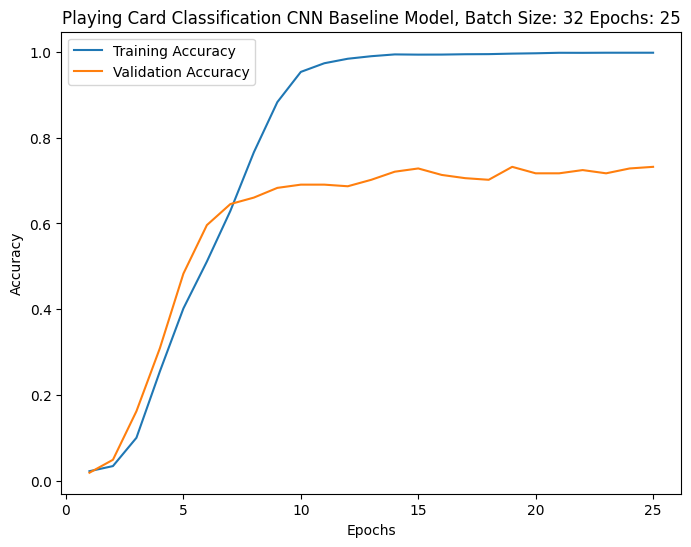

In [4]:
# Access the training history
train_accuracy = history_base.history['accuracy']
val_accuracy = history_base.history['val_accuracy']

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, cnn_epochs + 1), train_accuracy, label='Training Accuracy')
plt.plot(range(1, cnn_epochs + 1), val_accuracy, label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Playing Card Classification CNN Baseline Model, Batch Size: 32 Epochs: 25')
plt.legend()

# Show the plot
plt.show()

# Improved CNN Model
This cell defines and trains an improved Convolutional Neural Network (CNN) model for playing card image classification. The enhanced architecture includes additional convolutional and max-pooling layers, dropout layers for regularization, and increased complexity in the fully connected layers. The model is trained on a dataset loaded using TensorFlow's image dataset utilities, with normalization applied to the data. The training history, including accuracy, is stored in the variable history and can be visualized later for performance analysis.

In [5]:
cnn_epochs = 25
cnn_batchsize = 8
width = 150
height = 150
input_shape = (width, height, 3)
num_classes = 53

cnn_model = Sequential()
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
 
cnn_model.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
 
cnn_model.add(Dropout(0.25))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))
cnn_model.add(Dense(128, activation='relu'))
 
cnn_model.add(Dense(num_classes, activation='softmax'))
 
cnn_model.compile(loss="sparse_categorical_crossentropy", optimizer=keras.optimizers.SGD(), metrics=['accuracy'])

In [6]:
train = tf.keras.utils.image_dataset_from_directory(
  "train/",
  image_size=(width, height),
  batch_size=cnn_batchsize)
 
valid = tf.keras.utils.image_dataset_from_directory(
  'test/',
  image_size=(width, height),
  batch_size=cnn_batchsize)
 
train=train.map(lambda x,y:(x/255,y))
valid=valid.map(lambda x,y:(x/255,y))
 
train = train.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
valid = valid.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
 
history = cnn_model.fit(
  train,
  validation_data=valid,
  shuffle=True,  
  epochs=cnn_epochs
)

Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Epoch 1/25


2023-12-08 09:23:34.152414: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [7624]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:23:34.152706: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [7624]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:23:34.797297: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


952/953 [============================>.] - ETA: 0s - loss: 3.9664 - accuracy: 0.0211

2023-12-08 09:23:53.305686: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [265]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:23:53.306096: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [265]
	 [[{{node Placeholder/_0}}]]


953/953 [==============================] - 20s 19ms/step - loss: 3.9664 - accuracy: 0.0212 - val_loss: 3.9553 - val_accuracy: 0.0189
Epoch 2/25
953/953 [==============================] - 18s 19ms/step - loss: 3.7800 - accuracy: 0.0577 - val_loss: 3.0597 - val_accuracy: 0.1623
Epoch 3/25
953/953 [==============================] - 18s 19ms/step - loss: 2.9294 - accuracy: 0.1869 - val_loss: 2.1980 - val_accuracy: 0.3245
Epoch 4/25
953/953 [==============================] - 18s 19ms/step - loss: 2.3758 - accuracy: 0.3155 - val_loss: 1.7781 - val_accuracy: 0.4302
Epoch 5/25
953/953 [==============================] - 18s 19ms/step - loss: 2.1112 - accuracy: 0.3812 - val_loss: 1.5712 - val_accuracy: 0.4981
Epoch 6/25
953/953 [==============================] - 18s 19ms/step - loss: 1.9216 - accuracy: 0.4347 - val_loss: 1.3899 - val_accuracy: 0.5774
Epoch 7/25
953/953 [==============================] - 18s 19ms/step - loss: 1.7170 - accuracy: 0.5043 - val_loss: 1.2251 - val_accuracy: 0.6642
Epo

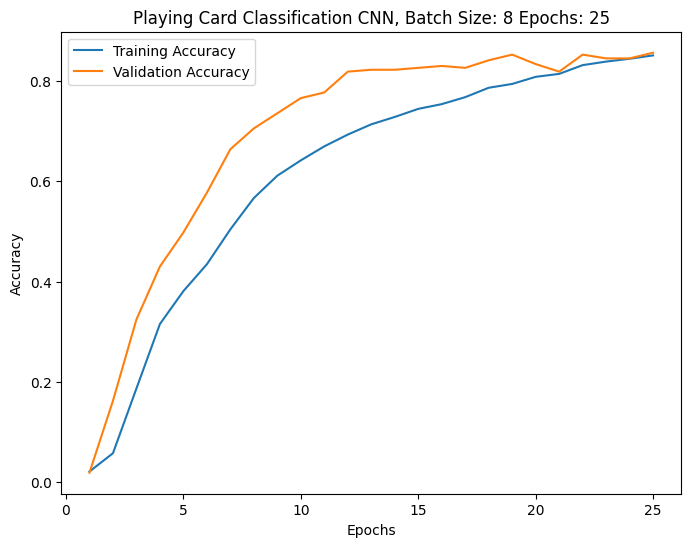

In [7]:
# Access the training history
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, cnn_epochs + 1), train_accuracy, label='Training Accuracy')
plt.plot(range(1, cnn_epochs + 1), val_accuracy, label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Playing Card Classification CNN, Batch Size: 8 Epochs: 25')
plt.legend()

# Show the plot
plt.show()

# DNN Model 

This cell defines and trains a Deep Neural Network (DNN) model for playing card image classification, utilizing the same batch size (8) and number of epochs (25) as the improved CNN model. The DNN architecture consists of fully connected layers with rectified linear unit (ReLU) activation functions and softmax activation for the output layer. The model is trained on a dataset loaded using TensorFlow's image dataset utilities, with data normalization applied. The training history, capturing accuracy, is stored in the variable history2 for subsequent analysis and visualization.

In [8]:
dnn_epochs = 25
dnn_batchsize = 8
num_classes = 53
dnn_model = Sequential()
dnn_model.add(Flatten())
dnn_model.add(Dense(128, activation='relu'))
dnn_model.add(Dense(128, activation='relu'))
dnn_model.add(Dense(num_classes, activation='softmax'))
 
dnn_model.compile(loss="sparse_categorical_crossentropy",optimizer=keras.optimizers.SGD(),metrics=['accuracy'])

In [9]:
train2 = tf.keras.utils.image_dataset_from_directory(
  "train",
  image_size=(150, 150),
  batch_size=dnn_batchsize)
 
valid2 = tf.keras.utils.image_dataset_from_directory(
  'test',
  image_size=(150, 150),
  batch_size=dnn_batchsize)
 
train2=train2.map(lambda x,y:(x/255,y))
valid2=valid2.map(lambda x,y:(x/255,y))
 
train2 = train2.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
valid2 = valid2.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
 
history2 = dnn_model.fit(train2, validation_data = valid2, epochs=dnn_epochs)

Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Epoch 1/25


2023-12-08 09:31:35.841359: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [7624]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:31:35.841647: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [7624]
	 [[{{node Placeholder/_0}}]]


952/953 [============================>.] - ETA: 0s - loss: 4.0121 - accuracy: 0.0194

2023-12-08 09:31:42.002396: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [265]
	 [[{{node Placeholder/_4}}]]
2023-12-08 09:31:42.002749: I tensorflow/core/common_runtime/executor.cc:1209] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [265]
	 [[{{node Placeholder/_0}}]]


953/953 [==============================] - 7s 6ms/step - loss: 4.0121 - accuracy: 0.0194 - val_loss: 3.9701 - val_accuracy: 0.0189
Epoch 2/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9675 - accuracy: 0.0228 - val_loss: 3.9721 - val_accuracy: 0.0189
Epoch 3/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9663 - accuracy: 0.0224 - val_loss: 3.9707 - val_accuracy: 0.0189
Epoch 4/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9622 - accuracy: 0.0248 - val_loss: 3.9725 - val_accuracy: 0.0189
Epoch 5/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9583 - accuracy: 0.0254 - val_loss: 3.9780 - val_accuracy: 0.0189
Epoch 6/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9536 - accuracy: 0.0261 - val_loss: 3.9762 - val_accuracy: 0.0226
Epoch 7/25
953/953 [==============================] - 5s 5ms/step - loss: 3.9493 - accuracy: 0.0266 - val_loss: 3.9705 - val_accuracy: 0.0226
Epoch 8/25
953/95

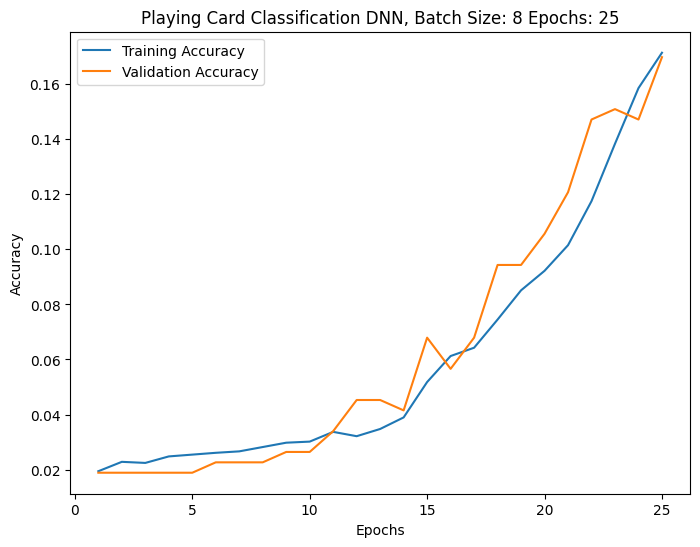

In [10]:
# Access the training history
train_accuracy = history2.history['accuracy']
val_accuracy = history2.history['val_accuracy']

# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, dnn_epochs + 1), train_accuracy, label='Training Accuracy')
plt.plot(range(1, dnn_epochs + 1), val_accuracy, label='Validation Accuracy')

# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Playing Card Classification DNN, Batch Size: 8 Epochs: 25')
plt.legend()

# Show the plot
plt.show()